In [23]:
import os

# 1. Force Keras backend to TensorFlow to prevent unwanted torch backend activation
os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

# 2. Fix for "module 'torch' has no attribute '_utils'"
# If PyTorch is present, pre-bind _utils so internal attribute lookups never fail
try:
    import torch
    import torch._utils
except (ImportError, AttributeError):
    pass

import numpy as np
from random import randint
from sklearn.utils import shuffle
from sklearn.preprocessing import MinMaxScaler

In [24]:
train_labels = []
train_samples = []

### Example Data

An experimental drug was tested on 2,100 individuals aged between 13 to 100 years:
- Half the participants were under 65 years old.
- Around ~95% of participants under 65 experienced no side effects (label `0`).
- Around ~5% of participants under 65 experienced side effects (label `1`).
- Around ~95% of participants 65 or older experienced side effects (label `1`).
- Around ~5% of participants 65 or older experienced no side effects (label `0`).

In [25]:
for i in range(50):
    # The ~5% of younger individuals who did experience side effects
    random_younger = randint(13, 64)
    train_samples.append(random_younger)
    train_labels.append(1) 

    # The ~5% of older individuals who did not experience side effects
    random_older = randint(65, 100)
    train_samples.append(random_older)
    train_labels.append(0)

for i in range(1000):
    # The ~95% of younger individuals who did not experience side effects
    random_younger = randint(13, 64)
    train_samples.append(random_younger)
    train_labels.append(0)

    # The ~95% of older individuals who did experience side effects
    random_older = randint(65, 100)
    train_samples.append(random_older)
    train_labels.append(1)

In [26]:
train_labels = np.array(train_labels)
train_samples = np.array(train_samples)
train_labels, train_samples = shuffle(train_labels, train_samples)

In [27]:
print(len(train_samples), train_samples[:5])
print(len(train_labels), train_labels[:5])

2100 [98 90 61 30 56]
2100 [1 1 0 0 0]


In [28]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train_samples = scaler.fit_transform(train_samples.reshape(-1, 1))
scaled_train_samples[:5]

array([[0.97701149],
       [0.88505747],
       [0.55172414],
       [0.1954023 ],
       [0.49425287]])

### Creating an Artificial Neural Network (ANN)

In [29]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import tensorflow as tf

# Robust Keras import: works seamlessly with both tensorflow.keras and standalone keras
try:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Input, Activation, Dense
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.metrics import categorical_crossentropy
except (ModuleNotFoundError, ImportError):
    import keras
    from keras.models import Sequential
    from keras.layers import Input, Activation, Dense
    from keras.optimizers import Adam
    from keras.metrics import categorical_crossentropy

In [30]:
model = Sequential([
    Input(shape=(1,)),
    Dense(units=16, activation='relu'),
    Dense(units=32, activation='relu'),
    Dense(units=2, activation='softmax')
])

In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 642 (2.51 KB)

 Trainable params: 642 (2.51 KB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

In [32]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
model.fit(
    x=scaled_train_samples,
    y=train_labels,
    validation_split=0.1,
    batch_size=10,
    shuffle=True,
    epochs=30,
    verbose=2
)

Epoch 1/30


189/189 - 1s - 3ms/step - accuracy: 0.5545 - loss: 0.6553 - val_accuracy: 0.5286 - val_loss: 0.6561
Epoch 2/30
189/189 - 0s - 1ms/step - accuracy: 0.6180 - loss: 0.6280 - val_accuracy: 0.6095 - val_loss: 0.6320
Epoch 3/30
189/189 - 0s - 1ms/step - accuracy: 0.6725 - loss: 0.6004 - val_accuracy: 0.6810 - val_loss: 0.6050
Epoch 4/30
189/189 - 0s - 1ms/step - accuracy: 0.7376 - loss: 0.5694 - val_accuracy: 0.7333 - val_loss: 0.5721
Epoch 5/30
189/189 - 0s - 1ms/step - accuracy: 0.7720 - loss: 0.5407 - val_accuracy: 0.7857 - val_loss: 0.5431
Epoch 6/30
189/189 - 0s - 1ms/step - accuracy: 0.7974 - loss: 0.5129 - val_accuracy: 0.8095 - val_loss: 0.5139
Epoch 7/30
189/189 - 0s - 1ms/step - accuracy: 0.8190 - loss: 0.4854 - val_accuracy: 0.8524 - val_loss: 0.4835
Epoch 8/30
189/189 - 0s - 1ms/step - accuracy: 0.8429 - loss: 0.4570 - val_accuracy: 0.8667 - val_loss: 0.4526
Epoch 9/30
189/189 - 0s - 1ms/step - accuracy: 0.8577 - loss: 0.4306 - val_accuracy: 0.8762 - val_loss: 0.4243
Epoch 10/30


### Building a Test Set and Predicting

In [34]:
test_labels = []
test_samples = []

In [35]:
for i in range(50):
    # The ~5% of younger individuals who did experience side effects
    random_younger = randint(13, 64)
    test_samples.append(random_younger)
    test_labels.append(1) 

    # The ~5% of older individuals who did not experience side effects
    random_older = randint(65, 100)
    test_samples.append(random_older)
    test_labels.append(0)

for i in range(1000):
    # The ~95% of younger individuals who did not experience side effects
    random_younger = randint(13, 64)
    test_samples.append(random_younger)
    test_labels.append(0)

    # The ~95% of older individuals who did experience side effects
    random_older = randint(65, 100)
    test_samples.append(random_older)
    test_labels.append(1)

test_labels = np.array(test_labels)
test_samples = np.array(test_samples)
test_labels, test_samples = shuffle(test_labels, test_samples)

scaled_test_samples = scaler.transform(test_samples.reshape(-1, 1))

In [36]:
predictions = model.predict(
    x=scaled_test_samples,
    batch_size=10,
    verbose=0
)

In [37]:
print(predictions[:5])

[[0.7329988  0.26700124]
 [0.41730246 0.5826975 ]
 [0.03228782 0.96771216]
 [0.95151126 0.04848878]
 [0.04515441 0.9548456 ]]


In [38]:
# Convert prediction probabilities to class index (0 or 1)
rounded_predictions = np.argmax(predictions, axis=-1)
rounded_predictions[:5]

array([0, 1, 1, 0, 1])

### Confusion Matrix for Accuracy Check

In [39]:
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import matplotlib.pyplot as plt

In [40]:
cm = confusion_matrix(y_true=test_labels, y_pred=rounded_predictions)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 959   91]
 [  49 1001]]


In [41]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    # Fixed typo: cm.shape[1] instead of cm.shae[1]
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, f"{cm[i, j]:.2f}" if normalize else str(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [42]:
cm_plot_labels = ['no_side_effects', 'had_side_effects']

Confusion matrix, without normalization
[[ 959   91]
 [  49 1001]]


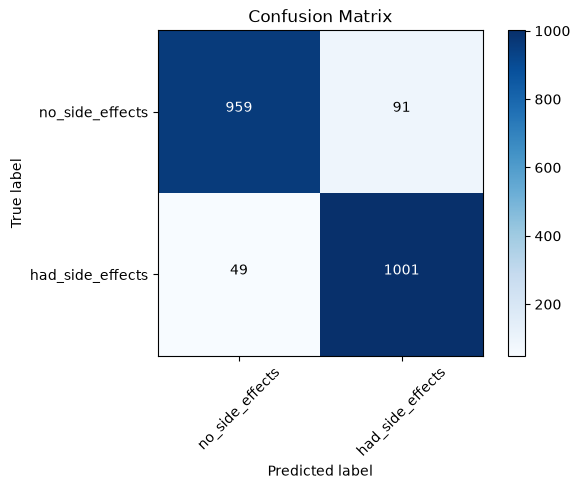

In [43]:
plot_confusion_matrix(cm=cm, classes=cm_plot_labels, title='Confusion Matrix')
plt.show()

In [44]:
print(classification_report(test_labels, rounded_predictions, target_names=cm_plot_labels))

                  precision    recall  f1-score   support

 no_side_effects       0.95      0.91      0.93      1050
had_side_effects       0.92      0.95      0.93      1050

        accuracy                           0.93      2100
       macro avg       0.93      0.93      0.93      2100
    weighted avg       0.93      0.93      0.93      2100



### Saving and Loading the Model

In [45]:
try:
    from tensorflow.keras.models import load_model
except (ModuleNotFoundError, ImportError):
    from keras.models import load_model

# 1. Save the model in Keras format (.keras)
model_path = 'medical_trial_model.keras'
model.save(model_path)
print(f"Model successfully saved to {model_path}")

# 2. Load the model back
new_model = load_model(model_path)
new_model.summary()

Model successfully saved to medical_trial_model.keras


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,928 (7.54 KB)

 Trainable params: 642 (2.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,286 (5.03 KB)